# M5: test-retest reliability (session 1 vs. session 2)

Replicates `ssveps/templateCode/ICCs/computeICC_gridMaps.m` -- for subjects
with both sessions, compute per-pixel ICC(A,1) (two-way random, absolute
agreement, single measurement -- McGraw & Wong 1996, matching the template's
MATLAB `ICC(..., 'A-1')`) between their session 1 and session 2 mean grids.
The result is a 10x10 "ICC map": which parts of the grid are measured more
or less reliably test-retest.

Python equivalent of the template's MATLAB `ICC.m` file-exchange function:
[`pingouin`](https://pingouin-stats.org/)'s `intraclass_corr`, whose
`'ICC(A,1)'` row is exactly this form (plus CI/F/p, matching the template's
output columns) -- added as a project dependency (`uv add pingouin`).

**To add or change which groups this whole notebook covers, edit only
`GROUP_SPECS` below** -- every later cell loops over `groups`/`icc_dfs`, so
one new entry (e.g. `{'label': 'CVD', 'group': 'CVD', 'subgroup': None}`)
carries through the ICC maps, the informative example points, and their
Bland-Altman/scatter plots with no other changes needed.

In [1]:
import sys
sys.path.append('../scripts')

from analysis import load_runmap, load_baselines, load_metadata, load_grid_axes, mean_grid_across_subjects, trough_location, DEFAULT_NORMALIZE
import reliability as rel
import plotting as pl

runmap_df = load_runmap()
baselines_df = load_baselines()
metadata_df = load_metadata()
red_vals, green_vals = load_grid_axes()

GROUP_SPECS = [
    {'label': 'all paired', 'group': None, 'subgroup': None},
    {'label': 'PD', 'group': 'PD', 'subgroup': None},
    {'label': 'HC', 'group': 'CTR', 'subgroup': None},
]

groups, icc_dfs, icc_maps, troughs = {}, {}, {}, {}
for spec in GROUP_SPECS:
    label = spec['label']
    sub_ids = rel.paired_subjects(metadata_df, group=spec['group'], subgroup=spec['subgroup'])
    groups[label] = sub_ids
    icc_dfs[label] = rel.icc_grid(runmap_df, baselines_df, sub_ids)
    icc_maps[label] = rel.icc_map(icc_dfs[label])
    # each group's own trough location (session 1), computed over the exact
    # same sub_ids used for that group's ICC map -- not re-derived via
    # group/subgroup filters, so it stays consistent with this subset
    troughs[label] = trough_location(
        mean_grid_across_subjects(runmap_df, baselines_df, sub_ids, 1, normalize=DEFAULT_NORMALIZE), red_vals, green_vals
    )
    print(f"{label:>10}: n={len(sub_ids)} {sub_ids}")

all paired: n=19 ['MET000', 'MET002', 'MET003', 'MET004', 'MET005', 'MET006', 'MET008', 'MET009', 'MET012', 'MET016', 'MET017', 'MET018', 'MET021', 'MET023', 'MET025', 'MET027', 'MET030', 'MET038', 'MET039']
        PD: n=4 ['MET025', 'MET030', 'MET038', 'MET039']
        HC: n=13 ['MET000', 'MET002', 'MET003', 'MET004', 'MET005', 'MET006', 'MET008', 'MET009', 'MET012', 'MET018', 'MET021', 'MET023', 'MET027']


## ICC maps, one per group
PD's paired sample is thin (n=4) -- read its map as illustrative, not a
robust reliability estimate.

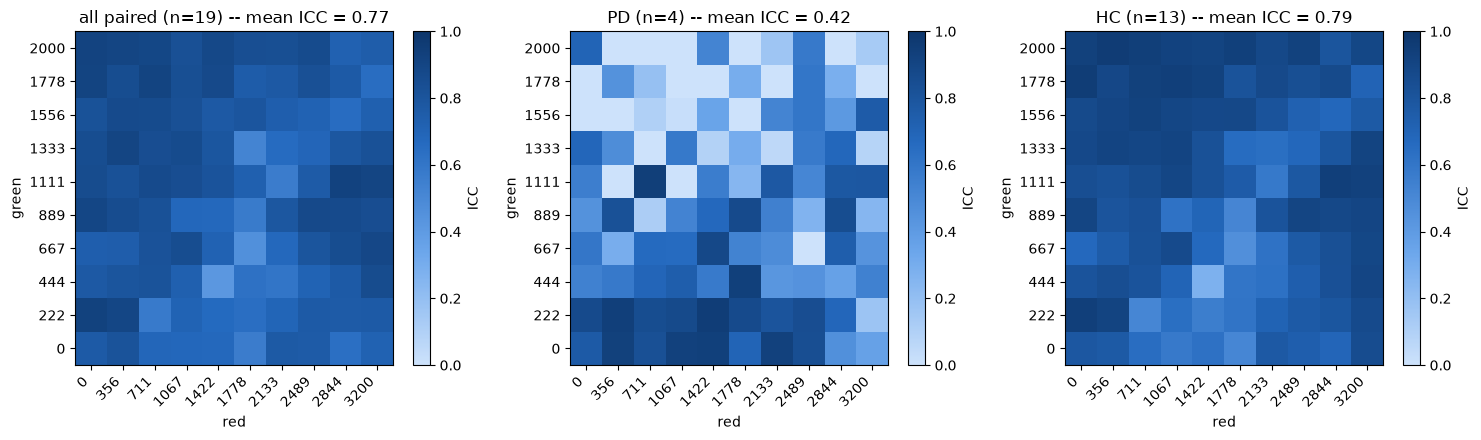

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 4.5))
for ax, label in zip(axes, groups):
    pl.plot_icc_map(icc_maps[label], title=f"{label} (n={len(groups[label])}) -- mean ICC = {icc_maps[label].mean():.2f}", ax=ax)
fig.tight_layout()

## Example-point agreement: Bland-Altman and session scatter
Replicates `ICC_BlantAltman_dists.m`'s example-point plots, via two point
selectors (your choice: both, as separate functions):
- `reliability.example_points_fixed` -- the template's own 5 hardcoded
  (red, green) targets, snapped to the nearest grid index. Fixed regardless
  of the data; useful for comparing against the original MATLAB analysis.
- `reliability.example_points_informative` -- data-driven: each group's own
  lowest-ICC pixel (worst reliability), highest-ICC pixel (best), and trough
  location (the pixel this project actually cares about scientifically).

### Fixed example points (template's 5 targets)
Shown for the full paired sample, matching the template's own treatment.

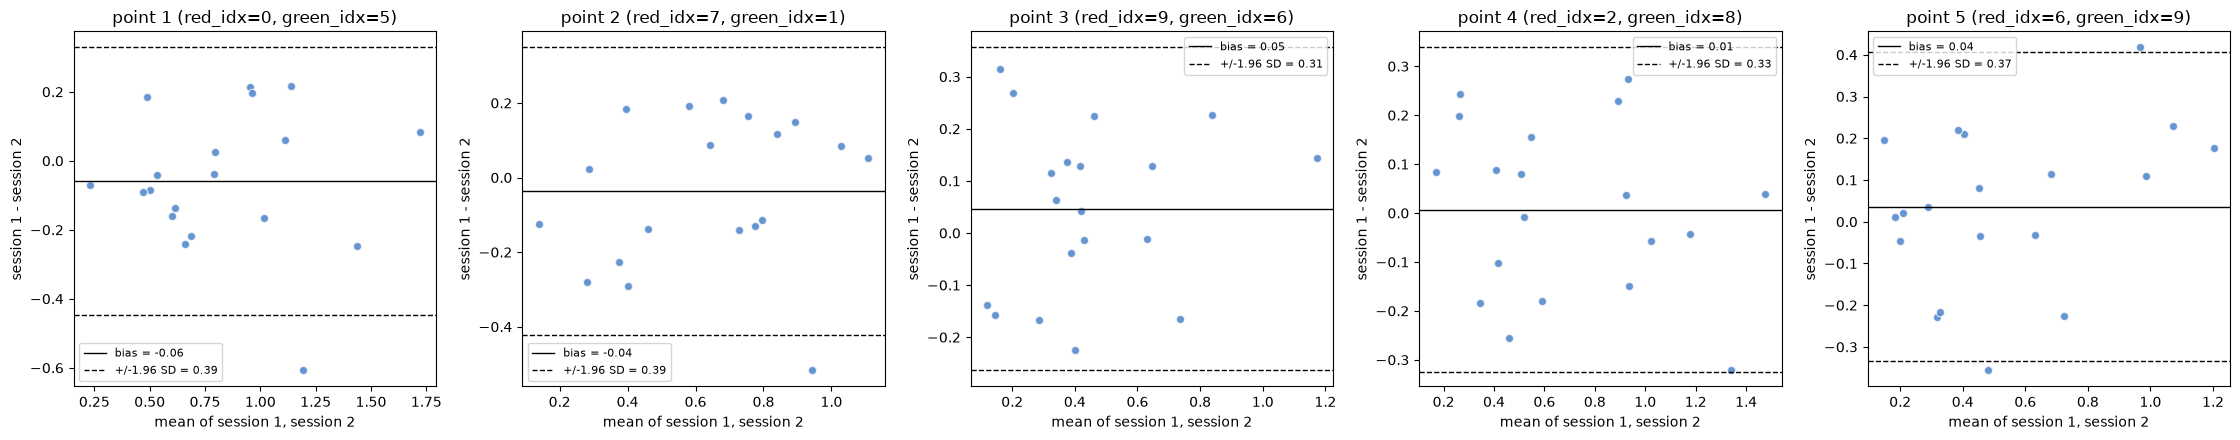

In [3]:
fixed_points = rel.example_points_fixed(red_vals, green_vals)
pl.plot_example_points(runmap_df, baselines_df, groups['all paired'], fixed_points, kind='bland_altman');

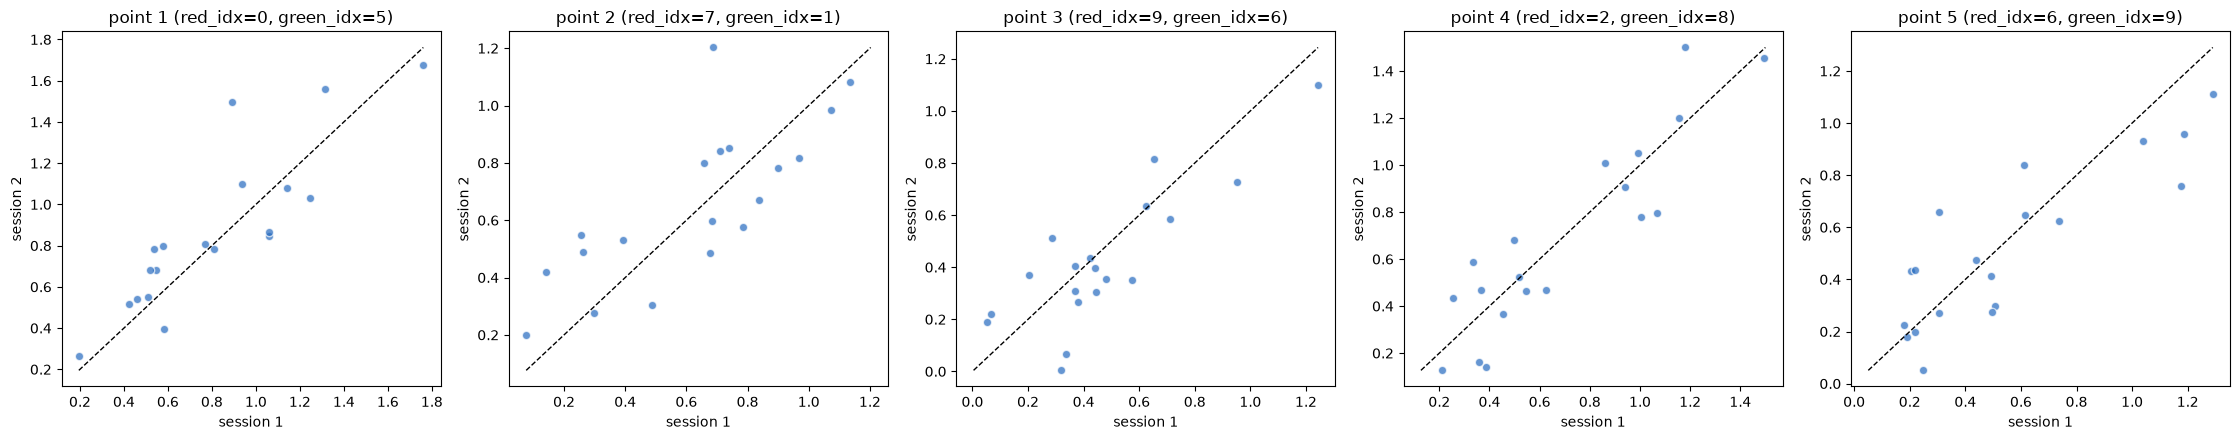

In [4]:
pl.plot_example_points(runmap_df, baselines_df, groups['all paired'], fixed_points, kind='scatter');

### Informative example points, per group
Lowest-ICC / highest-ICC / trough, for every group in `GROUP_SPECS`.

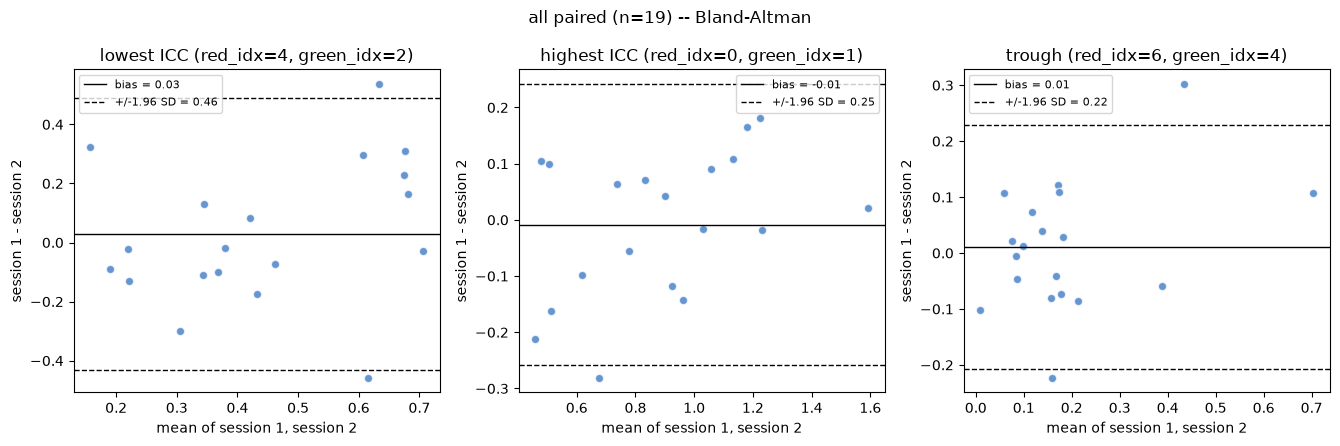

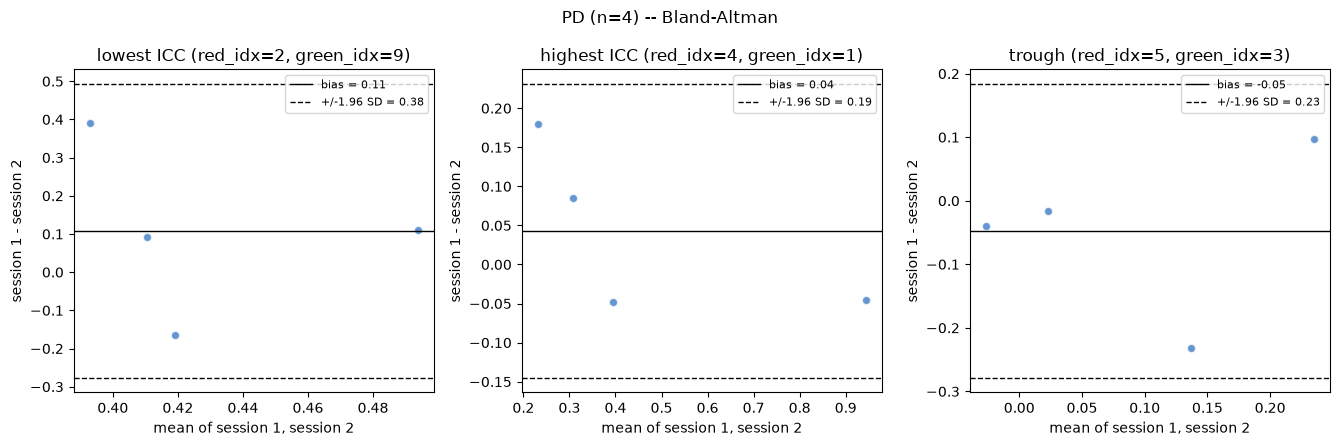

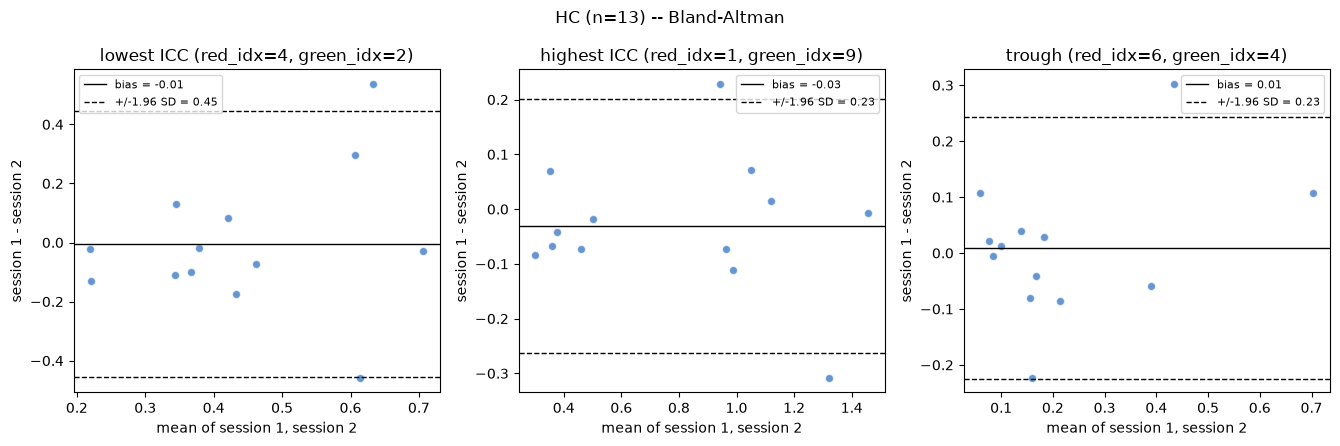

In [5]:
for label, sub_ids in groups.items():
    points = rel.example_points_informative(
        icc_dfs[label], trough_red_idx=troughs[label]['red_idx'], trough_green_idx=troughs[label]['green_idx'],
    )
    pl.plot_example_points(runmap_df, baselines_df, sub_ids, points, kind='bland_altman', title=f'{label} (n={len(sub_ids)}) -- Bland-Altman')

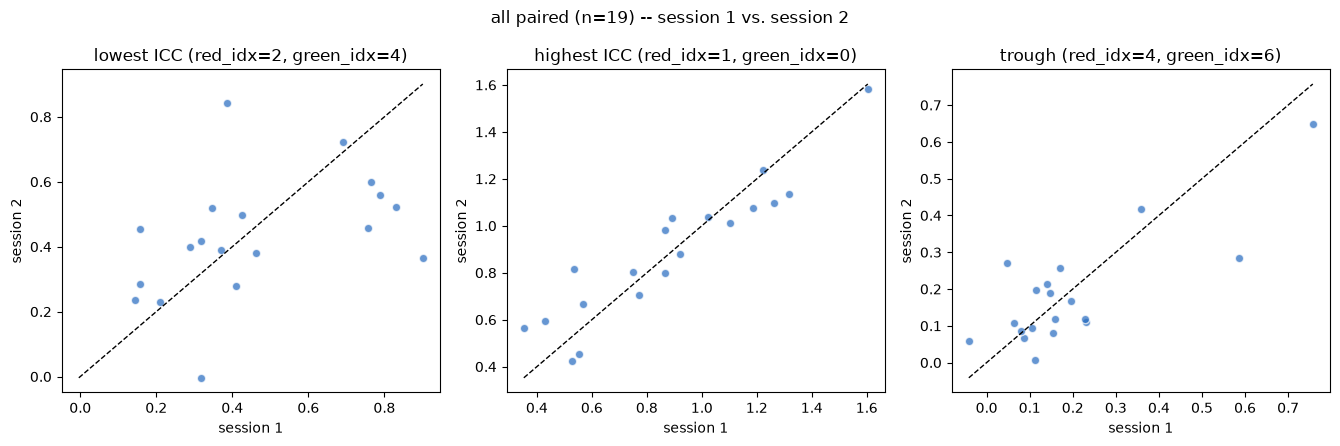

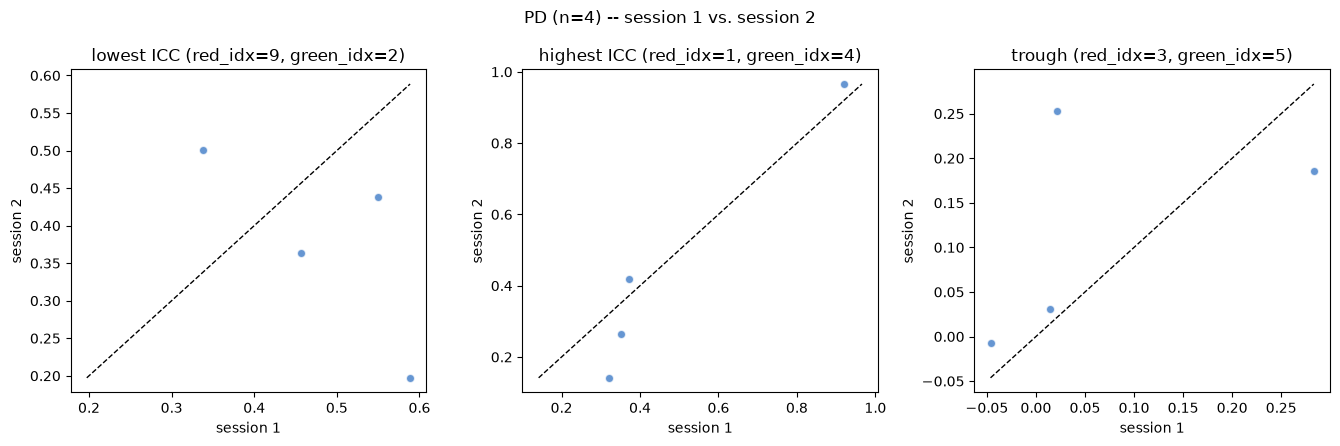

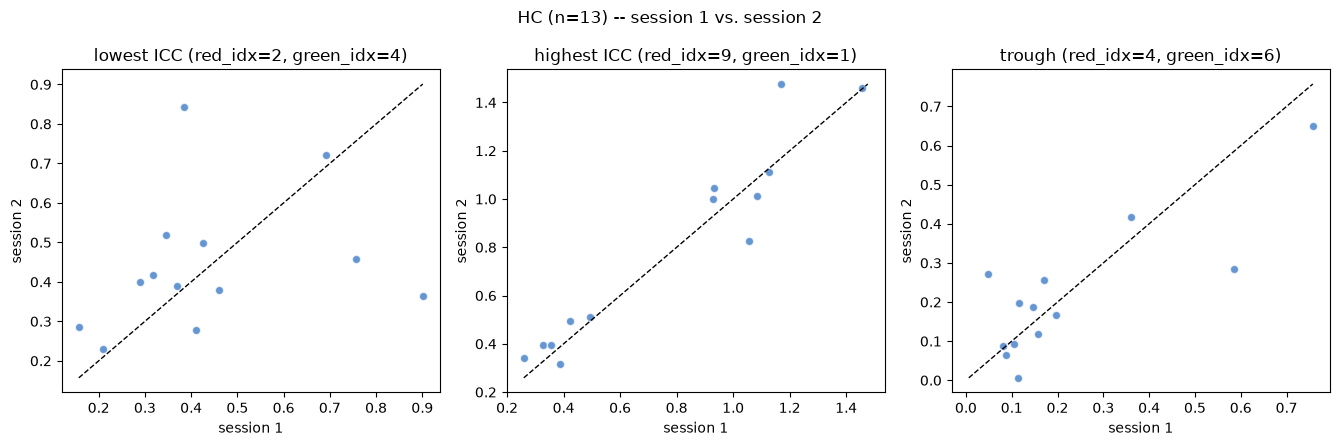

In [6]:
for label, sub_ids in groups.items():
    points = rel.example_points_informative(
        icc_dfs[label], trough_red_idx=troughs[label]['red_idx'], trough_green_idx=troughs[label]['green_idx'],
    )
    pl.plot_example_points(runmap_df, baselines_df, sub_ids, points, kind='scatter', title=f'{label} (n={len(sub_ids)}) -- session 1 vs. session 2')

## Notes
- `reliability.icc_grid` returns a tidy per-pixel table (`red_idx, green_idx,
  icc, ci_lower, ci_upper, f, df1, df2, pval`) -- `icc_map` pivots it to the
  10x10 array `plot_icc_map` expects. Not persisted to a CSV (like M3's
  permutation tests, this is a statistical result best viewed fresh with its
  own plot, and it's cheap to recompute -- a few seconds per group).
- `reliability.session_pair_values` returns the raw paired session
  1/session 2 values at one grid cell across subjects -- the data behind one
  `icc_grid` row, useful for a closer look (e.g. Bland-Altman) at a specific
  pixel; `plot_example_points` calls it internally for every point.
- Full parameter-by-parameter usage guidance (what to change to get raw vs.
  normalized values, fixed vs. data-driven points, a 4th group, etc.) is in
  `docs/api_reference.md`'s `reliability.py` and M5 plotting sections.